In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [15]:
#Ye ek Machine Learning algorithm hai jo:
#Decision tree banata hai (if-else rules)
#Classification problems solve karta hai
from sklearn.tree import DecisionTreeClassifier


In [16]:
from sklearn import metrics
#Ye ek module hai jo model ki performance check karne ke tools deta hai:
#Accuracy
#precision
#Recall
#F1-score

train_test_split → data divide karta hai,
DecisionTreeClassifier → model banata hai,
metrics → performance check karta hai,
classification_report → detailed result deta hai,

In [17]:
df=pd.read_csv("D:\python\practice\data\diabetes.csv")
df.drop(index=0)

<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
C:\Users\atasn\AppData\Local\Temp\ipykernel_11604\3915730572.py:1: SyntaxWarning: invalid escape sequence '\p'
  df=pd.read_csv("D:\python\practice\data\diabetes.csv")


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [18]:

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [19]:
feature_cols = ['pregnant', 'insulin', 'bmi', 'age', 
                'glucose', 'bp', 'pedigree']

X = df.drop('Outcome',axis=1)
y = df['Outcome']

In [20]:
X_train,X_test,Y_train,Y_test=train_test_split(
    X,y,test_size=0.25,random_state=16
)

In [21]:
clf=DecisionTreeClassifier()
clf.fit(X_train,Y_train)
Y_pred=clf.predict(X_test)

Confusion Matrix ek table hota hai jo classification model ki performance ko detail me show karta hai.
Diagonal values (TP, TN) → correct predictions 
Off-diagonal (FP, FN) → errors 

In [22]:
cnf_matrix=metrics.confusion_matrix(Y_test,Y_pred)
print(cnf_matrix)

[[103  22]
 [ 29  38]]


Text(50.722222222222214, 0.5, 'Actual')

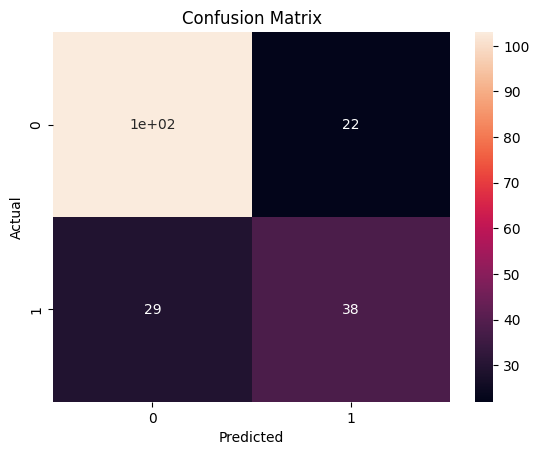

In [23]:
plt.figure()
sns.heatmap(cnf_matrix,annot=True)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

In [24]:
y.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [26]:
target_names = ['No Diabetes', 'Diabetes']

print(classification_report(Y_test, Y_pred, target_names=target_names))

              precision    recall  f1-score   support

 No Diabetes       0.78      0.82      0.80       125
    Diabetes       0.63      0.57      0.60        67

    accuracy                           0.73       192
   macro avg       0.71      0.70      0.70       192
weighted avg       0.73      0.73      0.73       192



In [28]:
print("Accuracy:",metrics.accuracy_score(Y_test, Y_pred))

Accuracy: 0.734375


: ROC Curve & AUC

ROC Curve → model performance at different thresholds
AUC → ek single number jo overall performance batata hai

ROC = Receiver Operating Characteristic
ROC curve ek graph hota hai jo dikhata hai:
X-axis: False Positive Rate (FPR)
Y-axis: True Positive Rate (TPR)

AUC batata hai:
“Model kitna acha hai positive aur negative ko separate karne mein”

“Threshold” ka matlab hota hai ek limit ya boundary value — yani wo point jahan par koi decision ya change hota hai.
Threshold ka use filtering ya conditions ke liye hota hai.